In [2]:
import os
from pathlib import Path
import sys
from urllib.request import urlretrieve

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from rich.console import Console
from rich.table import Table

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "tdmd").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tdmd import DCTTransform, TDMDII

plt.style.use("ggplot")

DATA_URL = "https://raw.githubusercontent.com/dynamicslab/databook_python/master/DATA/VORTALL.mat"
GRID_SHAPE = (199, 449)
SNAPSHOT_COUNT = 150


In [3]:
data_path = PROJECT_ROOT / "examples" / "data" / "VORTALL.mat"
data_path.parent.mkdir(parents=True, exist_ok=True)
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data_path


PosixPath('/content/tdmd-toolbox/examples/data/VORTALL.mat')

In [4]:
states = sio.loadmat(data_path)["VORTALL"][:, :SNAPSHOT_COUNT]
tensor = states.reshape(*GRID_SHAPE, SNAPSHOT_COUNT, order="F").transpose(0, 2, 1)
snapshot_idx = 50


In [5]:
gamma = 0.99999
model = TDMDII(DCTTransform(), gamma=gamma)
model.fit(tensor)

reconstructed_tensor = np.asarray(model.reconstructed_data).real
reconstructed_states = reconstructed_tensor.transpose(0, 2, 1).reshape(states.shape, order="F")
state_errors = np.array([
    np.linalg.norm(states[:, idx] - reconstructed_states[:, idx]) / np.linalg.norm(states[:, idx])
    for idx in range(states.shape[1])
])

snapshot_true = states[:, snapshot_idx].reshape(GRID_SHAPE, order="F")
snapshot_pred = reconstructed_tensor[:, snapshot_idx, :]
snapshot_re = float(state_errors[snapshot_idx])

table = Table(title="Cylinder Flow TDMDII")
table.add_column("Name", no_wrap=True)
table.add_column("Value")
table.add_row("state matrix shape", f"{tuple(states.shape)}")
table.add_row("k_max", f"{int(model.multirank.max())}")
table.add_row("sum k_j", f"{int(model.multirank.sum())}")
table.add_row("mean state-wise RE", f"{state_errors.mean():.4e}")
table.add_row("snapshot RE", f"{snapshot_re:.4e}")
Console().print(table)


        Cylinder Flow TDMDII         
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Name               ┃ Value        ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ state matrix shape │ (89351, 150) │
│ k_max              │ 16           │
│ sum k_j            │ 1478         │
│ mean state-wise RE │ 2.6860e-02   │
│ snapshot RE        │ 1.9203e-02   │
└────────────────────┴──────────────┘

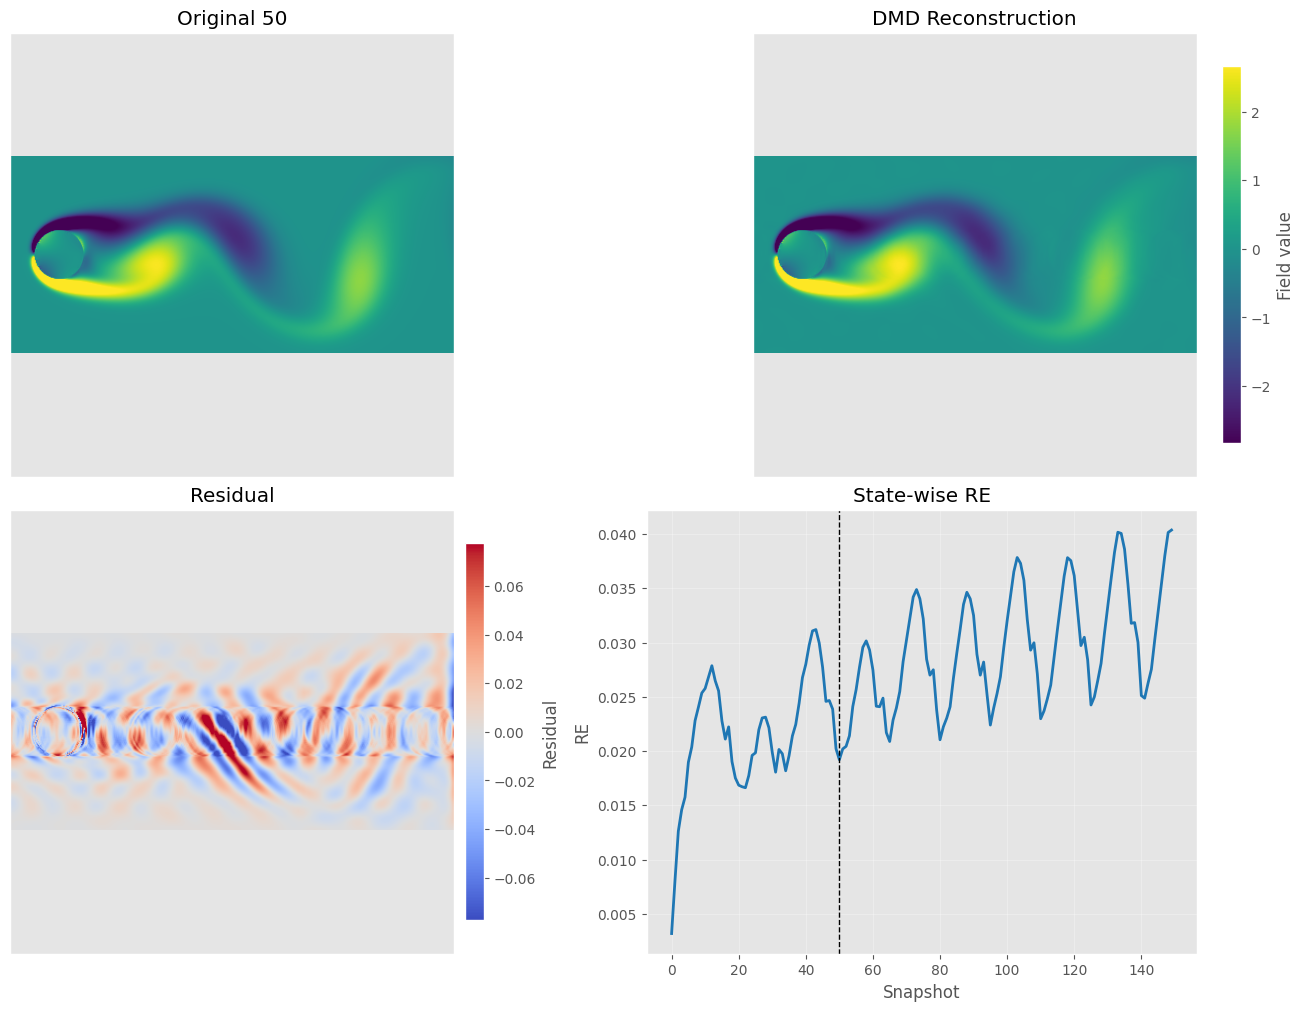

In [7]:
from matplotlib.colors import Normalize, TwoSlopeNorm


fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

img_axes = [axes[0, 0], axes[0, 1], axes[1, 0]]
plot_ax = axes[1, 1]

field_stack = np.stack([snapshot_true, snapshot_pred])
vmin = np.quantile(field_stack, 0.01)
vmax = np.quantile(field_stack, 0.99)
field_norm = Normalize(vmin=vmin, vmax=vmax)

im0 = img_axes[0].imshow(
    snapshot_true,
    origin="lower",
    cmap="viridis",
    norm=field_norm,
    aspect="equal",
)
img_axes[0].set_title(f"Original {snapshot_idx}")
img_axes[0].set_xticks([])
img_axes[0].set_yticks([])
img_axes[0].set_box_aspect(1)

im1 = img_axes[1].imshow(
    snapshot_pred,
    origin="lower",
    cmap="viridis",
    norm=field_norm,
    aspect="equal",
)
img_axes[1].set_title("DMD Reconstruction")
img_axes[1].set_xticks([])
img_axes[1].set_yticks([])
img_axes[1].set_box_aspect(1)

residual = snapshot_true - snapshot_pred
r = np.quantile(np.abs(residual), 0.99)
res_norm = TwoSlopeNorm(vmin=-r, vcenter=0.0, vmax=r)

im2 = img_axes[2].imshow(
    residual,
    origin="lower",
    cmap="coolwarm",
    norm=res_norm,
    aspect="equal",
)
img_axes[2].set_title("Residual")
img_axes[2].set_xticks([])
img_axes[2].set_yticks([])
img_axes[2].set_box_aspect(1)

plot_ax.plot(state_errors, linewidth=2, color="tab:blue")
plot_ax.axvline(snapshot_idx, color="black", linestyle="--", linewidth=1)
plot_ax.set_title("State-wise RE")
plot_ax.set_xlabel("Snapshot")
plot_ax.set_ylabel("RE")
plot_ax.grid(True, alpha=0.3)

fig.colorbar(im1, ax=[img_axes[0], img_axes[1]], shrink=0.85, pad=0.02, label="Field value")
fig.colorbar(im2, ax=img_axes[2], shrink=0.85, pad=0.02, label="Residual")

plt.show()